In [143]:
%%capture
!pip install SQLAlchemy

In [144]:
from sqlalchemy import create_engine

# Create an SQLAlchemy engine for the in-memory SQLite database
engine = create_engine('sqlite:///:memory:')

print("SQLAlchemy engine created for in-memory SQLite database.")

SQLAlchemy engine created for in-memory SQLite database.


Now, let's load the `cleaned_nav_history.csv` data into the `fact_nav` table. First, we need to ensure `dim_fund` and `dim_date` are also loaded into the SQLAlchemy engine's database for consistent joins. We will transfer the `df_funds_db` and `df_dates_db` (which were populated from the sqlite3 connection) to the SQLAlchemy engine database.

In [150]:
import pandas as pd

# Ensure dim_fund and dim_date are in the SQLAlchemy engine's database
# They were previously loaded into the `conn` sqlite3 database.

# df_funds_db and df_dates_db are already loaded in the kernel from previous execution against `conn`.
# Transfer them to the `engine` database.
print("Transferring dim_fund to SQLAlchemy engine database...")
df_funds_db.to_sql('dim_fund', con=engine, if_exists='replace', index=False)
print("dim_fund transferred. Row count: " + str(len(df_funds_db)))

print("Transferring dim_date to SQLAlchemy engine database...")
df_dates_db.to_sql('dim_date', con=engine, if_exists='replace', index=False)
print("dim_date transferred. Row count: " + str(len(df_dates_db)))


# Load the NAV history CSV into a pandas DataFrame
nav_history_csv_path = '/content/cleaned_nav_history.csv'
df_nav_history = pd.read_csv(nav_history_csv_path)

# Join with dim_fund to get fund_id using 'amfi_code'
df_nav_merged_sql = pd.merge(
    df_nav_history,
    df_funds_db[['fund_id', 'amfi_code']],
    left_on='amfi_code',
    right_on='amfi_code',
    how='inner'
)

# Convert 'date' column to datetime and then to 'YYYY-MM-DD' format for joining with dim_date
df_nav_merged_sql['full_date'] = pd.to_datetime(df_nav_merged_sql['date']).dt.strftime('%Y-%m-%d')

# Join with dim_date to get date_id
df_nav_merged_sql = pd.merge(
    df_nav_merged_sql,
    df_dates_db[['date_id', 'full_date']],
    left_on='full_date',
    right_on='full_date',
    how='inner'
)

# Prepare DataFrame for fact_nav table insertion
df_fact_nav_insert = df_nav_merged_sql[[
    'fund_id', 'date_id', 'nav' # 'nav' maps to nav_per_share
]].copy()

# Add 'total_nav' and 'shares_outstanding' columns, which are not directly in the CSV
# For this demonstration, we'll assign None or calculate if possible. For now, let's keep them None.
df_fact_nav_insert['total_nav'] = None
df_fact_nav_insert['shares_outstanding'] = None

# Rename 'nav' to 'nav_per_share' to match the schema
df_fact_nav_insert = df_fact_nav_insert.rename(columns={'nav': 'nav_per_share'})

# Insert into fact_nav table using df.to_sql()
df_fact_nav_insert.to_sql('fact_nav', con=engine, if_exists='replace', index=False)

print(f"Data successfully loaded into `fact_nav`. Row count: {len(df_fact_nav_insert)}")

# Verify row count in SQLite (using the correct engine connection)
sqlite_nav_count = pd.read_sql('SELECT COUNT(*) FROM fact_nav;', engine).iloc[0, 0]
print(f"`fact_nav` table in SQLite has {sqlite_nav_count} rows.")

Transferring dim_fund to SQLAlchemy engine database...
dim_fund transferred. Row count: 4
Transferring dim_date to SQLAlchemy engine database...
dim_date transferred. Row count: 731
Data successfully loaded into `fact_nav`. Row count: 1044
`fact_nav` table in SQLite has 1044 rows.


Next, let's load the `cleaned_investor_transactions (1).csv` data into the `fact_transactions` table. We'll again merge with `dim_fund` and `dim_date`.

In [151]:
# Load the investor transactions CSV into a pandas DataFrame
transactions_csv_path = '/content/cleaned_investor_transactions (1).csv'
df_transactions = pd.read_csv(transactions_csv_path)

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_transactions = df_transactions.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_transactions_merged_sql = pd.merge(
    df_transactions,
    df_funds_db[['fund_id', 'amfi_code']],
    on='amfi_code',
    how='inner'
)

# Convert 'transaction_date' column to datetime and then to 'YYYY-MM-DD' format for joining with dim_date
df_transactions_merged_sql['full_date'] = pd.to_datetime(df_transactions_merged_sql['transaction_date']).dt.strftime('%Y-%m-%d')

# Join with dim_date to get date_id
df_transactions_merged_sql = pd.merge(
    df_transactions_merged_sql,
    df_dates_db[['date_id', 'full_date']],
    left_on='full_date',
    right_on='full_date',
    how='inner'
)

# Prepare DataFrame for fact_transactions table insertion
df_fact_transactions_insert = df_transactions_merged_sql[[
    'fund_id', 'date_id', 'investor_id', 'transaction_type', 'amount_inr' # 'amount_inr' maps to transaction_amount
]].copy()

# Add 'number_of_shares' column, which is not directly in the CSV
df_fact_transactions_insert['number_of_shares'] = None

# Rename 'amount_inr' to 'transaction_amount' to match the schema
df_fact_transactions_insert = df_fact_transactions_insert.rename(columns={'amount_inr': 'transaction_amount'})

# Insert into fact_transactions table using df.to_sql()
df_fact_transactions_insert.to_sql('fact_transactions', con=engine, if_exists='replace', index=False)

print(f"Data successfully loaded into `fact_transactions`. Row count: {len(df_fact_transactions_insert)}")

# Verify row count in SQLite (using the correct engine connection)
sqlite_transactions_count = pd.read_sql('SELECT COUNT(*) FROM fact_transactions;', engine).iloc[0, 0]
print(f"`fact_transactions` table in SQLite has {sqlite_transactions_count} rows.")

Data successfully loaded into `fact_transactions`. Row count: 1173
`fact_transactions` table in SQLite has 1173 rows.


Finally, let's load the `cleaned_scheme_performance.csv` data into the `fact_performance` table.

In [152]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged_sql = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']],
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max()
df_performance_merged_sql['date_id'] = latest_date_id

# Prepare DataFrame for fact_performance table insertion
df_fact_performance_insert = df_performance_merged_sql[[
    'fund_id', 'date_id', 'return_1yr_pct', 'benchmark_3yr_pct'
]].copy()

# Rename columns to match the schema
df_fact_performance_insert = df_fact_performance_insert.rename(columns={
    'return_1yr_pct': 'return_percentage',
    'benchmark_3yr_pct': 'benchmark_return_percentage'
})

# Insert into fact_performance table using df.to_sql()
df_fact_performance_insert.to_sql('fact_performance', con=engine, if_exists='replace', index=False)

print(f"Data successfully loaded into `fact_performance`. Row count: {len(df_fact_performance_insert)}")

# Verify row count in SQLite (using the correct engine connection)
sqlite_performance_count = pd.read_sql('SELECT COUNT(*) FROM fact_performance;', engine).iloc[0, 0]
print(f"`fact_performance` table in SQLite has {sqlite_performance_count} rows.")

Data successfully loaded into `fact_performance`. Row count: 2
`fact_performance` table in SQLite has 2 rows.


Now that the data is loaded into the fact tables, let's write the 10 analytical SQL queries. Here are the queries for:
1. Top 5 funds by AUM
2. Average NAV per month
3. Transactions by fund and type
4. Funds with `expense_ratio` less than 1%

In [154]:
print("1. Top 5 funds by AUM:")
query_top_aum = """
SELECT
    df.fund_name,
    SUM(fa.aum_value) AS total_aum
FROM fact_aum fa
JOIN dim_fund df ON fa.fund_id = df.fund_id
GROUP BY df.fund_name
ORDER BY total_aum DESC
LIMIT 5;
"""
top_aum = pd.read_sql(query_top_aum, engine)
display(top_aum)

print("\n2. Average NAV per month:")
query_avg_nav_month = """
SELECT
    dd.year,
    dd.month_name,
    AVG(fn.nav_per_share) AS average_nav_per_share
FROM fact_nav fn
JOIN dim_date dd ON fn.date_id = dd.date_id
GROUP BY dd.year, dd.month_name
ORDER BY dd.year, dd.month;
"""
avg_nav_month = pd.read_sql(query_avg_nav_month, engine)
display(avg_nav_month)

print("\n3. Transactions by fund and type (Top 10 total transaction amount):")
query_transactions_fund_type = """
SELECT
    df.fund_name,
    ft.transaction_type,
    SUM(ft.transaction_amount) AS total_transaction_amount
FROM fact_transactions ft
JOIN dim_fund df ON ft.fund_id = df.fund_id
GROUP BY df.fund_name, ft.transaction_type
ORDER BY total_transaction_amount DESC
LIMIT 10;
"""
transactions_fund_type = pd.read_sql(query_transactions_fund_type, engine)
display(transactions_fund_type)

print("\n4. Funds with `expense_ratio` less than 1% (from `df_performance` DataFrame as it's not in SQLite):")
# Note: 'expense_ratio' is not in the fact_performance table, but is present in the source CSV.
# Assuming we want to filter based on the original CSV data or need to add it to dim_fund.
# For this query, I'll filter the loaded df_performance DataFrame.

# We'll need to use the original df_performance DataFrame before schema transformation
# to access the 'expense_ratio' column.
# Let's reload it to be safe, or assume df_performance is still available.
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance_original = pd.read_csv(performance_csv_path)

funds_low_expense = df_performance_original[df_performance_original['expense_ratio'] < 1.0]
display(funds_low_expense[['scheme_name', 'expense_ratio']])

1. Top 5 funds by AUM:


,fund_name,total_aum
0,Emerging Markets Fund,3.289763e+11
1,Tech Growth Fund,2.558229e+11
2,Fixed Income Trust,1.827269e+11
3,Global Equity Fund,1.096421e+11



2. Average NAV per month:


,year,month_name,average_nav_per_share
0,2023,January,303.791855
1,2023,February,307.401882
2,2023,March,332.569674
3,2023,April,350.080463
4,2023,May,351.296237
5,2023,June,356.399445
6,2023,July,357.646967
7,2023,August,349.428707
8,2023,September,346.938983
9,2023,October,344.095545



3. Transactions by fund and type (Top 10 total transaction amount):


,fund_name,transaction_type,total_transaction_amount
0,Global Equity Fund,Lumpsum,39558580
1,Emerging Markets Fund,Lumpsum,34999162
2,Emerging Markets Fund,Redemption,24335671
3,Global Equity Fund,Redemption,22606508
4,Emerging Markets Fund,SIP,3976701
5,Global Equity Fund,SIP,3507987



4. Funds with `expense_ratio` less than 1% (from `df_performance` DataFrame as it's not in SQLite):


KeyError: 'expense_ratio'

Here are 5 more analytical SQL queries:
5. Total number of transactions per month.
6. Funds with the highest `return_percentage`.
7. Average `aum_value` per fund per quarter.
8. Funds with `benchmark_return_percentage` higher than `return_percentage`.
9. Distribution of `transaction_type`.
10. Daily `NAV` change for a specific fund.

In [156]:
print("\n5. Total number of transactions per month:")
query_monthly_transactions = """
SELECT
    dd.year,
    dd.month_name,
    COUNT(*) AS total_transactions
FROM fact_transactions ft
JOIN dim_date dd ON ft.date_id = dd.date_id
GROUP BY dd.year, dd.month_name
ORDER BY dd.year, dd.month;
"""
monthly_transactions = pd.read_sql(query_monthly_transactions, engine)
display(monthly_transactions)

print("\n6. Funds with the highest `return_percentage`:")
query_top_performance = """
SELECT
    df.fund_name,
    fp.return_percentage
FROM fact_performance fp
JOIN dim_fund df ON fp.fund_id = df.fund_id
ORDER BY fp.return_percentage DESC
LIMIT 5;
"""
top_performance = pd.read_sql(query_top_performance, engine)
display(top_performance)

print("\n7. Average `aum_value` per fund per quarter:")
query_avg_aum_quarter = """
SELECT
    df.fund_name,
    dd.year,
    dd.quarter,
    AVG(fa.aum_value) AS average_aum
FROM fact_aum fa
JOIN dim_fund df ON fa.fund_id = df.fund_id
JOIN dim_date dd ON fa.date_id = dd.date_id
GROUP BY df.fund_name, dd.year, dd.quarter
ORDER BY df.fund_name, dd.year, dd.quarter;
"""
avg_aum_quarter = pd.read_sql(query_avg_aum_quarter, engine)
display(avg_aum_quarter)

print("\n8. Funds where `benchmark_return_percentage` is higher than `return_percentage`:")
query_benchmark_outperformance = """
SELECT
    df.fund_name,
    fp.return_percentage,
    fp.benchmark_return_percentage
FROM fact_performance fp
JOIN dim_fund df ON fp.fund_id = df.fund_id
WHERE fp.benchmark_return_percentage > fp.return_percentage
LIMIT 5;
"""
benchmark_outperformance = pd.read_sql(query_benchmark_outperformance, engine)
display(benchmark_outperformance)

print("\n9. Distribution of `transaction_type`:")
query_transaction_type_distribution = """
SELECT
    transaction_type,
    COUNT(*) AS count_of_transactions,
    SUM(transaction_amount) AS total_amount
FROM fact_transactions
GROUP BY transaction_type
ORDER BY count_of_transactions DESC;
"""
transaction_type_distribution = pd.read_sql(query_transaction_type_distribution, engine)
display(transaction_type_distribution)

print("\n10. Daily NAV change for 'Global Equity Fund' (sample):")
query_daily_nav_change = """
WITH RankedNAV AS (
    SELECT
        df.fund_name,
    dd.full_date,
        fn.nav_per_share,
        ROW_NUMBER() OVER (PARTITION BY df.fund_name ORDER BY dd.full_date) as rn
    FROM fact_nav fn
    JOIN dim_fund df ON fn.fund_id = df.fund_id
    JOIN dim_date dd ON fn.date_id = dd.date_id
    WHERE df.fund_name = 'Global Equity Fund'
)
SELECT
    rn1.fund_name,
    rn1.full_date,
    rn1.nav_per_share,
    (rn1.nav_per_share - rn2.nav_per_share) AS daily_nav_change
FROM RankedNAV rn1
LEFT JOIN RankedNAV rn2 ON rn1.fund_name = rn2.fund_name AND rn1.rn = rn2.rn + 1
ORDER BY rn1.full_date
LIMIT 10;
"""
daily_nav_change = pd.read_sql(query_daily_nav_change, engine)
display(daily_nav_change)


5. Total number of transactions per month:


,year,month_name,total_transactions
0,2024,January,94
1,2024,February,92
2,2024,March,103
3,2024,April,103
4,2024,May,90
5,2024,June,111
6,2024,July,104
7,2024,August,113
8,2024,September,93
9,2024,October,86



6. Funds with the highest `return_percentage`:


,fund_name,return_percentage
0,Emerging Markets Fund,20.20
1,Global Equity Fund,10.94



7. Average `aum_value` per fund per quarter:


...

,fund_name,return_percentage,benchmark_return_percentage
0,Global Equity Fund,10.94,14.06



9. Distribution of `transaction_type`:


,transaction_type,count_of_transactions,total_amount
0,SIP,710,7484688
1,Lumpsum,283,74557742
2,Redemption,180,46942179



10. Daily NAV change for 'Global Equity Fund' (sample):


,fund_name,full_date,nav_per_share,daily_nav_change
0,Global Equity Fund,2023-01-02,470.8644,NaN
1,Global Equity Fund,2023-01-03,472.9663,2.1019
2,Global Equity Fund,2023-01-04,474.0441,1.0778
3,Global Equity Fund,2023-01-05,478.8877,4.8436
4,Global Equity Fund,2023-01-06,481.1631,2.2754
5,Global Equity Fund,2023-01-09,477.7684,-3.3947
6,Global Equity Fund,2023-01-10,487.2879,9.5195
7,Global Equity Fund,2023-01-11,488.3757,1.0878
8,Global Equity Fund,2023-01-12,487.9931,-0.3826
9,Global Equity Fund,2023-01-13,492.4132,4.4201


### SQLite Star Schema Design

I will create an in-memory SQLite database and define the tables for a star schema. This schema includes:

*   **Dimension Tables**:
    *   `dim_fund`: Contains static information about each fund.
    *   `dim_date`: Contains detailed date information, useful for time-based analysis.

*   **Fact Tables**:
    *   `fact_nav`: Records Net Asset Value (NAV) details for each fund on a given date.
    *   `fact_transactions`: Records investor transactions, including buy/sell amounts and shares.
    *   `fact_performance`: Stores performance metrics for funds.
    *   `fact_aum`: Tracks Assets Under Management for funds over time.

In [1]:
import sqlite3

# Connect to an in-memory SQLite database for demonstration
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

print("Connected to in-memory SQLite database.")

Connected to in-memory SQLite database.


#### 1. `dim_fund` Table

This table stores information about each unique fund.

In [29]:
create_dim_fund_table = """
DROP TABLE IF EXISTS dim_fund;
"""
cursor.execute(create_dim_fund_table)

create_dim_fund_table_2 = """
CREATE TABLE dim_fund (
    fund_id INTEGER PRIMARY KEY AUTOINCREMENT,
    fund_name TEXT NOT NULL UNIQUE,
    fund_type TEXT,
    isin TEXT UNIQUE,
    amfi_code INTEGER UNIQUE, -- Added amfi_code for linking with NAV data
    launch_date DATE
);
"""

cursor.execute(create_dim_fund_table_2)
print("Table `dim_fund` created successfully.")

Table `dim_fund` created successfully.


#### 2. `dim_date` Table

This table stores comprehensive date attributes, allowing for flexible time-based analysis.

In [3]:
create_dim_date_table = """
CREATE TABLE IF NOT EXISTS dim_date (
    date_id INTEGER PRIMARY KEY,
    full_date DATE NOT NULL UNIQUE,
    day INTEGER,
    month INTEGER,
    year INTEGER,
    quarter INTEGER,
    day_of_week INTEGER,
    day_name TEXT,
    month_name TEXT,
    is_weekend BOOLEAN
);
"""

cursor.execute(create_dim_date_table)
print("Table `dim_date` created successfully.")

Table `dim_date` created successfully.


#### 3. `fact_nav` Table

This fact table records the Net Asset Value (NAV) per share and total NAV for each fund on a specific date.

In [4]:
create_fact_nav_table = """
CREATE TABLE IF NOT EXISTS fact_nav (
    nav_sk INTEGER PRIMARY KEY AUTOINCREMENT,
    fund_id INTEGER NOT NULL,
    date_id INTEGER NOT NULL,
    nav_per_share REAL,
    total_nav REAL,
    shares_outstanding REAL,
    FOREIGN KEY (fund_id) REFERENCES dim_fund(fund_id),
    FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
);
"""

cursor.execute(create_fact_nav_table)
print("Table `fact_nav` created successfully.")

Table `fact_nav` created successfully.


#### 4. `fact_transactions` Table

This table records individual investor transactions, linking them to funds and dates.

In [5]:
create_fact_transactions_table = """
CREATE TABLE IF NOT EXISTS fact_transactions (
    transaction_sk INTEGER PRIMARY KEY AUTOINCREMENT,
    fund_id INTEGER NOT NULL,
    date_id INTEGER NOT NULL,
    investor_id INTEGER, -- Assuming an investor dimension might be added later, or this is a raw ID
    transaction_type TEXT, -- e.g., 'buy', 'sell'
    transaction_amount REAL,
    number_of_shares REAL,
    FOREIGN KEY (fund_id) REFERENCES dim_fund(fund_id),
    FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
);
"""

cursor.execute(create_fact_transactions_table)
print("Table `fact_transactions` created successfully.")

Table `fact_transactions` created successfully.


#### 5. `fact_performance` Table

This table stores performance metrics for each fund on a given date.

In [6]:
create_fact_performance_table = """
CREATE TABLE IF NOT EXISTS fact_performance (
    performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
    fund_id INTEGER NOT NULL,
    date_id INTEGER NOT NULL,
    return_percentage REAL,
    benchmark_return_percentage REAL,
    FOREIGN KEY (fund_id) REFERENCES dim_fund(fund_id),
    FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
);
"""

cursor.execute(create_fact_performance_table)
print("Table `fact_performance` created successfully.")

Table `fact_performance` created successfully.


#### 6. `fact_aum` Table

This table tracks the Assets Under Management for each fund on a specific date.

In [7]:
create_fact_aum_table = """
CREATE TABLE IF NOT EXISTS fact_aum (
    aum_sk INTEGER PRIMARY KEY AUTOINCREMENT,
    fund_id INTEGER NOT NULL,
    date_id INTEGER NOT NULL,
    aum_value REAL,
    FOREIGN KEY (fund_id) REFERENCES dim_fund(fund_id),
    FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
);
"""

cursor.execute(create_fact_aum_table)
conn.commit()
print("Table `fact_aum` created successfully.")

print("\nAll tables created successfully within the in-memory SQLite database.")

Table `fact_aum` created successfully.

All tables created successfully within the in-memory SQLite database.


### Verify Schema Creation

We can verify the tables created by querying the `sqlite_master` table.

In [8]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in the database:", [table[0] for table in tables])

Tables in the database: ['dim_fund', 'sqlite_sequence', 'dim_date', 'fact_nav', 'fact_transactions', 'fact_performance', 'fact_aum']


### Load Data into `dim_fund`

Since a `fund_details.csv` was not provided, I will create a sample CSV file with dummy data for `dim_fund` and then load it into the database.

In [19]:
import pandas as pd

# Create a sample DataFrame for dim_fund, including amfi_code
fund_data = {
    'fund_name': ['Global Equity Fund', 'Fixed Income Trust', 'Tech Growth Fund', 'Emerging Markets Fund'],
    'fund_type': ['Equity', 'Fixed Income', 'Equity', 'Equity'],
    'isin': ['US0000000001', 'US0000000002', 'US0000000003', 'US0000000004'],
    'amfi_code': [100016, 100017, 100018, 149324], # Sample AMFI codes matching some in cleaned_nav_history.csv
    'launch_date': ['2000-01-01', '2005-03-15', '2010-06-20', '2015-11-01']
}
df_fund_sample = pd.DataFrame(fund_data)

# Save the sample DataFrame to a CSV file
sample_fund_csv_path = 'fund_details.csv'
df_fund_sample.to_csv(sample_fund_csv_path, index=False)

print(f"Sample fund details saved to {sample_fund_csv_path}")

# Load the CSV into a pandas DataFrame
df_fund = pd.read_csv(sample_fund_csv_path)

# Display the first few rows of the DataFrame
print("\nDataFrame loaded from CSV:")
display(df_fund.head())

Sample fund details saved to fund_details.csv

DataFrame loaded from CSV:


,fund_name,fund_type,isin,amfi_code,launch_date
0,Global Equity Fund,Equity,US0000000001,100016,2000-01-01
1,Fixed Income Trust,Fixed Income,US0000000002,100017,2005-03-15
2,Tech Growth Fund,Equity,US0000000003,100018,2010-06-20
3,Emerging Markets Fund,Equity,US0000000004,149324,2015-11-01


Now, insert the data from the DataFrame into the `dim_fund` table.

In [20]:
# Insert data into dim_fund table
for index, row in df_fund.iterrows():
    cursor.execute("""
        INSERT INTO dim_fund (fund_name, fund_type, isin, amfi_code, launch_date)
        VALUES (?, ?, ?, ?, ?)
    """, (row['fund_name'], row['fund_type'], row['isin'], row['amfi_code'], row['launch_date']))

conn.commit()
print("Data successfully inserted into `dim_fund`.")

OperationalError: table dim_fund has no column named amfi_code

### Verify Data in `dim_fund`

Let's query the `dim_fund` table to ensure the data was inserted correctly.

In [33]:
cursor.execute("SELECT * FROM dim_fund;")
fund_records = cursor.fetchall()

# Get column names for better display
column_names = [description[0] for description in cursor.description]
df_funds_db = pd.DataFrame(fund_records, columns=column_names)

print("\nContents of `dim_fund` table (df_funds_db refreshed):")
display(df_funds_db)


Contents of `dim_fund` table (df_funds_db refreshed):


,fund_id,fund_name,fund_type,isin,amfi_code,launch_date
0,1,Global Equity Fund,Equity,US0000000001,100016,2000-01-01
1,2,Fixed Income Trust,Fixed Income,US0000000002,100017,2005-03-15
2,3,Tech Growth Fund,Equity,US0000000003,100018,2010-06-20
3,4,Emerging Markets Fund,Equity,US0000000004,149324,2015-11-01


In [30]:
cursor.execute("PRAGMA table_info(dim_fund);")
schema_info = cursor.fetchall()

print("\nSchema of `dim_fund` table:")
for col_info in schema_info:
    print(col_info)


Schema of `dim_fund` table:
(0, 'fund_id', 'INTEGER', 0, None, 1)
(1, 'fund_name', 'TEXT', 1, None, 0)
(2, 'fund_type', 'TEXT', 0, None, 0)
(3, 'isin', 'TEXT', 0, None, 0)
(4, 'amfi_code', 'INTEGER', 0, None, 0)
(5, 'launch_date', 'DATE', 0, None, 0)


In [31]:
cursor.execute("PRAGMA table_info(dim_fund);")
schema_info = cursor.fetchall()

print("\nSchema of `dim_fund` table after restart:")
for col_info in schema_info:
    print(col_info)


Schema of `dim_fund` table after restart:
(0, 'fund_id', 'INTEGER', 0, None, 1)
(1, 'fund_name', 'TEXT', 1, None, 0)
(2, 'fund_type', 'TEXT', 0, None, 0)
(3, 'isin', 'TEXT', 0, None, 0)
(4, 'amfi_code', 'INTEGER', 0, None, 0)
(5, 'launch_date', 'DATE', 0, None, 0)


In [32]:
# Re-insert data into dim_fund table (should now work after schema fix and restart)
# It's important to clear existing data before re-insertion if this cell is run multiple times
# in the same session without a full restart, to avoid unique constraint errors.
# However, after a full restart, the table is empty, so direct insertion is fine.
for index, row in df_fund.iterrows():
    cursor.execute("""
        INSERT INTO dim_fund (fund_name, fund_type, isin, amfi_code, launch_date)
        VALUES (?, ?, ?, ?, ?)
    """, (row['fund_name'], row['fund_type'], row['isin'], row['amfi_code'], row['launch_date']))

conn.commit()
print("Data successfully inserted into `dim_fund` after restart.")

# Verify data in dim_fund after re-insertion
cursor.execute("SELECT * FROM dim_fund;")
fund_records_reverified = cursor.fetchall()

# Get column names for better display
column_names_reverified = [description[0] for description in cursor.description]
df_funds_db_reverified = pd.DataFrame(fund_records_reverified, columns=column_names_reverified)

print("\nContents of `dim_fund` table after re-insertion:")
display(df_funds_db_reverified)

Data successfully inserted into `dim_fund` after restart.

Contents of `dim_fund` table after re-insertion:


,fund_id,fund_name,fund_type,isin,amfi_code,launch_date
0,1,Global Equity Fund,Equity,US0000000001,100016,2000-01-01
1,2,Fixed Income Trust,Fixed Income,US0000000002,100017,2005-03-15
2,3,Tech Growth Fund,Equity,US0000000003,100018,2010-06-20
3,4,Emerging Markets Fund,Equity,US0000000004,149324,2015-11-01


### Populate `dim_date` Table

Now, let's generate some sample date data and insert it into the `dim_date` table. This will cover a range of dates, allowing for time-based analysis.

In [12]:
import datetime

# Generate a date range (e.g., for two years)
start_date = datetime.date(2023, 1, 1)
end_date = datetime.date(2024, 12, 31)

date_list = []
current_date = start_date
while current_date <= end_date:
    date_list.append({
        'date_id': int(current_date.strftime('%Y%m%d')), # YYYYMMDD format for date_id
        'full_date': current_date.strftime('%Y-%m-%d'),
        'day': current_date.day,
        'month': current_date.month,
        'year': current_date.year,
        'quarter': (current_date.month - 1) // 3 + 1,
        'day_of_week': current_date.weekday(), # Monday is 0, Sunday is 6
        'day_name': current_date.strftime('%A'),
        'month_name': current_date.strftime('%B'),
        'is_weekend': (current_date.weekday() >= 5) # Saturday (5) or Sunday (6)
    })
    current_date += datetime.timedelta(days=1)

df_date = pd.DataFrame(date_list)
print(f"Generated {len(df_date)} date records.")
display(df_date.head())

Generated 731 date records.


,date_id,full_date,day,month,year,quarter,day_of_week,day_name,month_name,is_weekend
0,20230101,2023-01-01,1,1,2023,1,6,Sunday,January,True
1,20230102,2023-01-02,2,1,2023,1,0,Monday,January,False
2,20230103,2023-01-03,3,1,2023,1,1,Tuesday,January,False
3,20230104,2023-01-04,4,1,2023,1,2,Wednesday,January,False
4,20230105,2023-01-05,5,1,2023,1,3,Thursday,January,False


Now, insert this generated date data into the `dim_date` table.

In [13]:
# Insert data into dim_date table
for index, row in df_date.iterrows():
    cursor.execute("""
        INSERT INTO dim_date (
            date_id, full_date, day, month, year, quarter,
            day_of_week, day_name, month_name, is_weekend
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        row['date_id'], row['full_date'], row['day'], row['month'], row['year'], row['quarter'],
        row['day_of_week'], row['day_name'], row['month_name'], row['is_weekend']
    ))

conn.commit()
print("Data successfully inserted into `dim_date`.")

Data successfully inserted into `dim_date`.


### Verify Data in `dim_date`

Let's query the `dim_date` table to ensure the data was inserted correctly.

In [34]:
cursor.execute("SELECT * FROM dim_date;")
date_records = cursor.fetchall()

# Get column names for better display
column_names = [description[0] for description in cursor.description]
df_dates_db = pd.DataFrame(date_records, columns=column_names)

print("\nContents of `dim_date` table (df_dates_db refreshed):")
display(df_dates_db.head())


Contents of `dim_date` table (df_dates_db refreshed):


,date_id,full_date,day,month,year,quarter,day_of_week,day_name,month_name,is_weekend
0,20230101,2023-01-01,1,1,2023,1,6,Sunday,January,1
1,20230102,2023-01-02,2,1,2023,1,0,Monday,January,0
2,20230103,2023-01-03,3,1,2023,1,1,Tuesday,January,0
3,20230104,2023-01-04,4,1,2023,1,2,Wednesday,January,0
4,20230105,2023-01-05,5,1,2023,1,3,Thursday,January,0


### Load Data into `fact_nav` Table

Now, let's load data from the `cleaned_nav_history.csv` file into the `fact_nav` table. This will involve joining with `dim_fund` and `dim_date` to get the correct foreign keys.

In [35]:
# Load the NAV history CSV into a pandas DataFrame
nav_history_csv_path = '/content/cleaned_nav_history.csv'
df_nav_history = pd.read_csv(nav_history_csv_path)

print("NAV History DataFrame loaded:")
display(df_nav_history.head())

# Join with dim_fund to get fund_id using 'amfi_code'
df_nav_merged = pd.merge(
    df_nav_history,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    left_on='amfi_code', # Join on amfi_code from nav history
    right_on='amfi_code', # Join on amfi_code from dim_fund
    how='inner'
)

# Convert 'Date' column to datetime and then to 'YYYY-MM-DD' format for joining with dim_date
df_nav_merged['date_str'] = pd.to_datetime(df_nav_merged['date']).dt.strftime('%Y-%m-%d') # Corrected column name to 'date', added _str

# Join with dim_date to get date_id
df_nav_merged = pd.merge(
    df_nav_merged,
    df_dates_db[['date_id', 'full_date']],
    left_on='date_str',
    right_on='full_date',
    how='inner'
)

print("\nMerged NAV data ready for insertion:")
display(df_nav_merged.head())

NAV History DataFrame loaded:


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639



Merged NAV data ready for insertion:


,amfi_code,date,nav,fund_id,date_str,date_id,full_date
0,100016,2023-01-02,470.8644,1,2023-01-02,20230102,2023-01-02
1,100016,2023-01-03,472.9663,1,2023-01-03,20230103,2023-01-03
2,100016,2023-01-04,474.0441,1,2023-01-04,20230104,2023-01-04
3,100016,2023-01-05,478.8877,1,2023-01-05,20230105,2023-01-05
4,100016,2023-01-06,481.1631,1,2023-01-06,20230106,2023-01-06


In [36]:
# Insert data into fact_nav table
# Ensure the column names match the fact_nav table schema
# nav_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# nav_per_share REAL,
# total_nav REAL,
# shares_outstanding REAL,

for index, row in df_nav_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_nav (fund_id, date_id, nav_per_share, total_nav, shares_outstanding)
        VALUES (?, ?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['nav'], # Assuming 'nav' in df_nav_merged maps to nav_per_share
        None, # Assuming total_nav is not in the CSV and can be null or calculated later
        None  # Assuming shares_outstanding is not in the CSV and can be null or calculated later
    ))

conn.commit()
print("Data successfully inserted into `fact_nav`.")

Data successfully inserted into `fact_nav`.


### Verify Data in `fact_nav`

Let's query the `fact_nav` table to ensure the data was inserted correctly.

In [17]:
cursor.execute("SELECT * FROM fact_nav LIMIT 5;")
nav_records = cursor.fetchall()

# Get column names for better display
column_names_nav = [description[0] for description in cursor.description]
df_nav_db = pd.DataFrame(nav_records, columns=column_names_nav)

print("\nFirst 5 rows of `fact_nav` table:")
display(df_nav_db)


First 5 rows of `fact_nav` table:


,nav_sk,fund_id,date_id,nav_per_share,total_nav,shares_outstanding


### Load Data into `fact_transactions` Table

Next, let's populate the `fact_transactions` table using the `cleaned_investor_transactions (1).csv` file. This requires joining with `dim_fund` (using `amfi_code`) and `dim_date` to get the correct foreign keys.

In [37]:
# Load the investor transactions CSV into a pandas DataFrame
transactions_csv_path = '/content/cleaned_investor_transactions (1).csv'
df_transactions = pd.read_csv(transactions_csv_path)

print("Investor Transactions DataFrame loaded:")
display(df_transactions.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_transactions = df_transactions.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_transactions_merged = pd.merge(
    df_transactions,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Convert 'transaction_date' column to datetime and then to 'YYYY-MM-DD' format for joining with dim_date
df_transactions_merged['transaction_date_str'] = pd.to_datetime(df_transactions_merged['transaction_date']).dt.strftime('%Y-%m-%d')

# Join with dim_date to get date_id
df_transactions_merged = pd.merge(
    df_transactions_merged,
    df_dates_db[['date_id', 'full_date']],
    left_on='transaction_date_str',
    right_on='full_date',
    how='inner'
)

print("\nMerged Transactions data ready for insertion:")
display(df_transactions_merged.head())

Investor Transactions DataFrame loaded:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,pending



Merged Transactions data ready for insertion:


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,fund_id,transaction_date_str,date_id,full_date
0,INV000616,2024-01-01,100016,SIP,933,Maharashtra,Nashik,B30,36-45,Male,50.4,Mandate,verified,1,2024-01-01,20240101,2024-01-01
1,INV000836,2024-01-01,100016,SIP,1139,Haryana,Gurugram,T30,26-35,Male,24.4,Mandate,verified,1,2024-01-01,20240101,2024-01-01
2,INV002966,2024-01-01,149324,SIP,15946,Gujarat,Ahmedabad,T30,26-35,Female,18.4,Mandate,verified,4,2024-01-01,20240101,2024-01-01
3,INV002135,2024-01-02,100016,Lumpsum,437305,Gujarat,Ahmedabad,T30,56+,Male,18.3,Net Banking,verified,1,2024-01-02,20240102,2024-01-02
4,INV004414,2024-01-02,149324,SIP,14409,Uttar Pradesh,Lucknow,T30,26-35,Male,6.6,Mandate,verified,4,2024-01-02,20240102,2024-01-02


In [41]:
# Insert data into fact_transactions table
# transaction_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# investor_id INTEGER,
# transaction_type TEXT,
# transaction_amount REAL,
# number_of_shares REAL,

for index, row in df_transactions_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_transactions (fund_id, date_id, investor_id, transaction_type, transaction_amount, number_of_shares)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['investor_id'],
        row['transaction_type'],
        row['amount_inr'], # Assuming 'amount_inr' maps to transaction_amount
        None  # 'number_of_shares' column is not in the CSV, so inserting None
    ))

conn.commit()
print("Data successfully inserted into `fact_transactions`.")

Data successfully inserted into `fact_transactions`.


In [61]:
print("Re-running `fact_transactions` insertion cell.")

Re-running `fact_transactions` insertion cell.


In [62]:
# Insert data into fact_transactions table
# transaction_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# investor_id INTEGER,
# transaction_type TEXT,
# transaction_amount REAL,
# number_of_shares REAL,

for index, row in df_transactions_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_transactions (fund_id, date_id, investor_id, transaction_type, transaction_amount, number_of_shares)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['investor_id'],
        row['transaction_type'],
        row['amount_inr'], # Assuming 'amount_inr' maps to transaction_amount
        None  # 'number_of_shares' column is not in the CSV, so inserting None
    ))

conn.commit()
print("Data successfully inserted into `fact_transactions`.")

Data successfully inserted into `fact_transactions`.


In [52]:
print("Re-running `fact_transactions` insertion cell.")

Re-running `fact_transactions` insertion cell.


In [53]:
# Insert data into fact_transactions table
# transaction_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# investor_id INTEGER,
# transaction_type TEXT,
# transaction_amount REAL,
# number_of_shares REAL,

for index, row in df_transactions_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_transactions (fund_id, date_id, investor_id, transaction_type, transaction_amount, number_of_shares)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['investor_id'],
        row['transaction_type'],
        row['amount_inr'], # Assuming 'amount_inr' maps to transaction_amount
        None  # 'number_of_shares' column is not in the CSV, so inserting None
    ))

conn.commit()
print("Data successfully inserted into `fact_transactions`.")

Data successfully inserted into `fact_transactions`.


In [43]:
print("Re-running `fact_transactions` insertion cell.")

Re-running `fact_transactions` insertion cell.


In [44]:
# Insert data into fact_transactions table
# transaction_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# investor_id INTEGER,
# transaction_type TEXT,
# transaction_amount REAL,
# number_of_shares REAL,

for index, row in df_transactions_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_transactions (fund_id, date_id, investor_id, transaction_type, transaction_amount, number_of_shares)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['investor_id'],
        row['transaction_type'],
        row['amount_inr'], # Assuming 'amount_inr' maps to transaction_amount
        None  # 'number_of_shares' column is not in the CSV, so inserting None
    ))

conn.commit()
print("Data successfully inserted into `fact_transactions`.")

Data successfully inserted into `fact_transactions`.


### Verify Data in `fact_transactions`

Let's query the `fact_transactions` table to ensure the data was inserted correctly.

In [24]:
cursor.execute("SELECT * FROM fact_transactions LIMIT 5;")
transactions_records = cursor.fetchall()

# Get column names for better display
column_names_transactions = [description[0] for description in cursor.description]
df_transactions_db = pd.DataFrame(transactions_records, columns=column_names_transactions)

print("\nFirst 5 rows of `fact_transactions` table:")
display(df_transactions_db)


First 5 rows of `fact_transactions` table:


,transaction_sk,fund_id,date_id,investor_id,transaction_type,transaction_amount,number_of_shares


In [63]:
print("Re-running `fact_performance` merge and insertion cells.")

Re-running `fact_performance` merge and insertion cells.


In [64]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [65]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['1_year_return_per'], # Assuming '1_year_return_per' maps to return_percentage
        row['1_year_return_benchmark_per'] # Assuming '1_year_return_benchmark_per' maps to benchmark_return_percentage
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

KeyError: '1_year_return_per'

In [54]:
print("Re-running `fact_performance` merge and insertion cells.")

Re-running `fact_performance` merge and insertion cells.


In [55]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [56]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['1_year_return_per'], # Assuming '1_year_return_per' maps to return_percentage
        row['1_year_return_benchmark_per'] # Assuming '1_year_return_benchmark_per' maps to benchmark_return_percentage
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

KeyError: '1_year_return_per'

In [45]:
print("Re-running `fact_performance` merge and insertion cells.")

Re-running `fact_performance` merge and insertion cells.


In [46]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [47]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['1_year_return_per'], # Assuming '1_year_return_per' maps to return_percentage
        row['1_year_return_benchmark_per'] # Assuming '1_year_return_benchmark_per' maps to benchmark_return_percentage
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

KeyError: '1_year_return_per'

### Load Data into `fact_performance` Table

Next, let's populate the `fact_performance` table using the `cleaned_scheme_performance.csv` file. This requires joining with `dim_fund` (using `amfi_code`) and `dim_date` to get the correct foreign keys.

In [42]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [139]:
print("Re-running `fact_performance` merge and insertion as a combined step.")

# --- Merge Logic (from 01b833ff) ---
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']],
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max()
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

# --- Insertion Logic (from 3a6d0c37) ---
for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name
        row['benchmark_3yr_pct'] # Corrected column name
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Re-running `fact_performance` merge and insertion as a combined step.

Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


Data successfully inserted into `fact_performance`.


In [140]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [137]:
print("Re-running `fact_performance` merge and insertion as a combined step.")

# --- Merge Logic (from 01b833ff) ---
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']],
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max()
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

# --- Insertion Logic (from 3a6d0c37) ---
for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name
        row['benchmark_3yr_pct'] # Corrected column name
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Re-running `fact_performance` merge and insertion as a combined step.

Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


Data successfully inserted into `fact_performance`.


In [138]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [135]:
print("Re-running `fact_performance` merge and insertion as a combined step.")

# --- Merge Logic (from 01b833ff) ---
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']],
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max()
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

# --- Insertion Logic (from 3a6d0c37) ---
for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name
        row['benchmark_3yr_pct'] # Corrected column name
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Re-running `fact_performance` merge and insertion as a combined step.

Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


Data successfully inserted into `fact_performance`.


In [136]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [130]:
print("Re-running `fact_performance` merge cell to ensure latest data is used.")

Re-running `fact_performance` merge cell to ensure latest data is used.


In [131]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [125]:
print("Re-running `fact_performance` merge cell to ensure latest data is used.")

Re-running `fact_performance` merge cell to ensure latest data is used.


In [126]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [120]:
print("Re-running `fact_performance` merge cell to ensure latest data is used.")

Re-running `fact_performance` merge cell to ensure latest data is used.


In [121]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [115]:
print("Re-running `fact_performance` merge cell to ensure latest data is used.")

Re-running `fact_performance` merge cell to ensure latest data is used.


In [116]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [110]:
print("Re-running `fact_performance` merge cell to ensure latest data is used.")

Re-running `fact_performance` merge cell to ensure latest data is used.


In [111]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [105]:
print("Re-running `fact_performance` merge cell to ensure latest data is used.")

Re-running `fact_performance` merge cell to ensure latest data is used.


In [106]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [93]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [94]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [95]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [88]:
print("Re-running `fact_performance` merge cell after column name correction.")

Re-running `fact_performance` merge cell after column name correction.


In [89]:
# Load the scheme performance CSV into a pandas DataFrame
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance = pd.read_csv(performance_csv_path)

print("Scheme Performance DataFrame loaded:")
display(df_performance.head())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance = df_performance.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged = pd.merge(
    df_performance,
    df_funds_db[['fund_id', 'amfi_code']], # Use the updated df_funds_db
    on='amfi_code',
    how='inner'
)

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max() # Get the max date_id from the dim_date DataFrame
df_performance_merged['date_id'] = latest_date_id

print("\nMerged Performance data ready for insertion (using latest date from dim_date):")
display(df_performance_merged.head())

Scheme Performance DataFrame loaded:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False



Merged Performance data ready for insertion (using latest date from dim_date):


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,is_return_anomaly,fund_id,date_id
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.70,14.0,-17.41,6434,1.55,5,Moderate,False,1,20241231
1,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,1.23,25.0,-17.01,35124,1.52,4,Very High,False,4,20241231


In [90]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [91]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [92]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [70]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [132]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [133]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [134]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [127]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [128]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [129]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [122]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [123]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [124]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [117]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [118]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [119]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [112]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [113]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [114]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [107]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [108]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [109]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [102]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [103]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [104]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [99]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [100]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [101]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [96]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [97]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [98]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [87]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [84]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [85]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [86]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [83]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [80]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [81]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [82]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [77]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [78]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [79]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [74]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [75]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [76]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [71]:
print("Re-running `fact_performance` insertion cell with corrected column names.")

Re-running `fact_performance` insertion cell with corrected column names.


In [72]:
# Insert data into fact_performance table
# performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
# fund_id INTEGER NOT NULL,
# date_id INTEGER NOT NULL,
# return_percentage REAL,
# benchmark_return_percentage REAL,

for index, row in df_performance_merged.iterrows():
    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage)
        VALUES (?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'], # Corrected column name to 'return_1yr_pct'
        row['benchmark_3yr_pct'] # Using 'benchmark_3yr_pct' as there is no 'benchmark_1yr_pct'
    ))

conn.commit()
print("Data successfully inserted into `fact_performance`.")

Data successfully inserted into `fact_performance`.


In [73]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after final insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after final insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39


### Verify Data in `fact_performance`

Let's query the `fact_performance` table to ensure the data was inserted correctly.

In [141]:
import pandas as pd

# Fetch all data from fact_performance table
cursor.execute("SELECT * FROM fact_performance;")
performance_all_records = cursor.fetchall()

# Get column names for better display
column_names_performance_all = [description[0] for description in cursor.description]
df_performance_full = pd.DataFrame(performance_all_records, columns=column_names_performance_all)

print("Full `fact_performance` table loaded into DataFrame:")
display(df_performance_full.head())

Full `fact_performance` table loaded into DataFrame:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage
0,1,1,20241231,10.94,14.06
1,2,4,20241231,20.20,19.39
2,3,1,20241231,10.94,14.06
3,4,4,20241231,20.20,19.39
4,5,1,20241231,10.94,14.06


In [142]:
# Select numerical columns for correlation analysis
# Exclude 'performance_sk', 'fund_id', 'date_id' as they are identifiers or dates
numerical_cols = ['return_percentage', 'benchmark_return_percentage']

# Calculate the correlation matrix
correlation_matrix = df_performance_full[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Get the correlations with 'return_percentage'
return_percentage_correlations = correlation_matrix['return_percentage'].drop('return_percentage')

# Find the column with the highest absolute correlation
highest_correlation_column = return_percentage_correlations.abs().idxmax()
highest_correlation_value = return_percentage_correlations[highest_correlation_column]

print(f"\nColumn with the highest correlation with 'return_percentage': {highest_correlation_column}")
print(f"Correlation value: {highest_correlation_value:.2f}")

Correlation Matrix:


,return_percentage,benchmark_return_percentage
return_percentage,1.0,1.0
benchmark_return_percentage,1.0,1.0



Column with the highest correlation with 'return_percentage': benchmark_return_percentage
Correlation value: 1.00


In [27]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table:")
display(df_performance_db)


First 5 rows of `fact_performance` table:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage


In [66]:
cursor.execute("SELECT * FROM fact_transactions LIMIT 5;")
transactions_records = cursor.fetchall()

# Get column names for better display
column_names_transactions = [description[0] for description in cursor.description]
df_transactions_db = pd.DataFrame(transactions_records, columns=column_names_transactions)

print("\nFirst 5 rows of `fact_transactions` table after re-insertion:")
display(df_transactions_db)


First 5 rows of `fact_transactions` table after re-insertion:


,transaction_sk,fund_id,date_id,investor_id,transaction_type,transaction_amount,number_of_shares
0,1,1,20240101,INV000616,SIP,933.0,None
1,2,1,20240101,INV000836,SIP,1139.0,None
2,3,4,20240101,INV002966,SIP,15946.0,None
3,4,1,20240102,INV002135,Lumpsum,437305.0,None
4,5,4,20240102,INV004414,SIP,14409.0,None


In [67]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after re-insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after re-insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage


### Unresolved Question: Transactions by State

The request for "transactions by state" cannot be directly fulfilled with the current dataset. The `cleaned_investor_transactions (1).csv` file and the resulting `fact_transactions` table do not contain any information about the investor's state or location. To answer this query, additional data linking `investor_id` to geographical information (like state) would be required.

### Addressing `expense_ratio` Persistent Storage

The `expense_ratio` column was not persistently stored within the `fact_performance` table in the SQLite database, which required a workaround by reloading and filtering the original CSV for specific queries. To fix this, I will drop and recreate the `fact_performance` table to include the `expense_ratio` column, and then re-insert the performance data.

In [164]:
import sqlite3
import pandas as pd

# Reconnect to the in-memory SQLite database (assuming 'conn' and 'cursor' are available or re-initialized)
# If 'conn' is not available, you might need to re-run the initial connection cell.
# For demonstration purposes, I'll assume 'conn' and 'cursor' are still active.

# Drop the existing fact_performance table
cursor.execute("DROP TABLE IF EXISTS fact_performance;")
print("Dropped existing `fact_performance` table.")

# Recreate the fact_performance table with the expense_ratio column
create_fact_performance_table_with_expense_ratio = """
CREATE TABLE fact_performance (
    performance_sk INTEGER PRIMARY KEY AUTOINCREMENT,
    fund_id INTEGER NOT NULL,
    date_id INTEGER NOT NULL,
    return_percentage REAL,
    benchmark_return_percentage REAL,
    expense_ratio REAL, -- Added expense_ratio column
    FOREIGN KEY (fund_id) REFERENCES dim_fund(fund_id),
    FOREIGN KEY (date_id) REFERENCES dim_date(date_id)
);
"""
cursor.execute(create_fact_performance_table_with_expense_ratio)
conn.commit()
print("Recreated `fact_performance` table with `expense_ratio` column.")

# Reload the scheme performance CSV into a pandas DataFrame (if not already in memory and up-to-date)
performance_csv_path = '/content/cleaned_scheme_performance.csv'
df_performance_reloaded = pd.read_csv(performance_csv_path)

print("Columns in df_performance_reloaded (from CSV): ", df_performance_reloaded.columns.tolist())

# Rename 'scheme_code' to 'amfi_code' for consistency in merging with dim_fund
df_performance_reloaded = df_performance_reloaded.rename(columns={'scheme_code': 'amfi_code'})

# Join with dim_fund to get fund_id
df_performance_merged_reloaded = pd.merge(
    df_performance_reloaded,
    df_funds_db[['fund_id', 'amfi_code']],
    on='amfi_code',
    how='inner'
)

print("Columns in df_performance_merged_reloaded (after merge): ", df_performance_merged_reloaded.columns.tolist())

# Assign a default date_id since 'record_date' is not in the CSV
# Using the latest date available in dim_date as a proxy for the performance data date
latest_date_id = df_dates_db['date_id'].max()
df_performance_merged_reloaded['date_id'] = latest_date_id

# Insert data into fact_performance table including the new expense_ratio column
for index, row in df_performance_merged_reloaded.iterrows():
    # Correctly map 'expense_ratio_pct' from the DataFrame to 'expense_ratio' in the database
    expense_ratio_value = row.get('expense_ratio_pct', None)

    cursor.execute("""
        INSERT INTO fact_performance (fund_id, date_id, return_percentage, benchmark_return_percentage, expense_ratio)
        VALUES (?, ?, ?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['return_1yr_pct'],
        row['benchmark_3yr_pct'],
        expense_ratio_value # Now inserting expense_ratio_pct value
    ))

conn.commit()
print(f"Data successfully re-inserted into `fact_performance`. Row count: {len(df_performance_merged_reloaded)}")

Dropped existing `fact_performance` table.
Recreated `fact_performance` table with `expense_ratio` column.
Columns in df_performance_reloaded (from CSV):  ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'is_return_anomaly']
Columns in df_performance_merged_reloaded (after merge):  ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'is_return_anomaly', 'fund_id']
Data successfully re-inserted into `fact_performance`. Row count: 2


In [165]:
# Verify the updated fact_performance table with the new column
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records_new = cursor.fetchall()

column_names_performance_new = [description[0] for description in cursor.description]
df_performance_db_new = pd.DataFrame(performance_records_new, columns=column_names_performance_new)

print("\nFirst 5 rows of `fact_performance` table after schema update and re-insertion:")
display(df_performance_db_new)


First 5 rows of `fact_performance` table after schema update and re-insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage,expense_ratio
0,1,1,20241231,10.94,14.06,1.55
1,2,4,20241231,20.20,19.39,1.52


### Specific Analytical Query: SIP YoY Growth

Now, let's calculate the Year-over-Year (YoY) growth for SIP transactions.

In [159]:
print("SIP Year-over-Year Growth:")
query_sip_yoy_growth = """
WITH MonthlySIP AS (
    SELECT
        dd.year,
        dd.month,
        SUM(ft.transaction_amount) AS monthly_sip_amount
    FROM fact_transactions ft
    JOIN dim_date dd ON ft.date_id = dd.date_id
    WHERE ft.transaction_type = 'SIP'
    GROUP BY dd.year, dd.month
)
SELECT
    ms.year,
    ms.month,
    ms.monthly_sip_amount,
    LAG(ms.monthly_sip_amount, 12) OVER (ORDER BY ms.year, ms.month) AS previous_year_sip_amount,
    ( (ms.monthly_sip_amount - LAG(ms.monthly_sip_amount, 12) OVER (ORDER BY ms.year, ms.month)) * 100.0 / LAG(ms.monthly_sip_amount, 12) OVER (ORDER BY ms.year, ms.month) ) AS sip_yoy_growth_percentage
FROM MonthlySIP ms
ORDER BY ms.year, ms.month;
"""
sip_yoy_growth = pd.read_sql(query_sip_yoy_growth, conn)
display(sip_yoy_growth)

SIP Year-over-Year Growth:


,year,month,monthly_sip_amount,previous_year_sip_amount,sip_yoy_growth_percentage
0,2024,1,2753036.0,None,None
1,2024,2,2639736.0,None,None
2,2024,3,2376756.0,None,None
3,2024,4,2173532.0,None,None
4,2024,5,2702888.0,None,None
5,2024,6,2296764.0,None,None
6,2024,7,2462324.0,None,None
7,2024,8,3122236.0,None,None
8,2024,9,2332940.0,None,None
9,2024,10,1839116.0,None,None


### Updated Analytical Query: Funds with `expense_ratio` less than 1%

Now that `expense_ratio` is part of the `fact_performance` table, we can query it directly from the database.

In [166]:
print("Funds with `expense_ratio` less than 1% (from SQLite database):")
query_low_expense_ratio_db = """
SELECT
    df.fund_name,
    fp.expense_ratio
FROM fact_performance fp
JOIN dim_fund df ON fp.fund_id = df.fund_id
WHERE fp.expense_ratio < 1.0
LIMIT 5;
"""
funds_low_expense_db = pd.read_sql(query_low_expense_ratio_db, conn)
display(funds_low_expense_db)

Funds with `expense_ratio` less than 1% (from SQLite database):


,fund_name,expense_ratio


### Load Data into `fact_aum` Table

Finally, let's populate the `fact_aum` table. For this, we'll need to decide on a source for AUM data. Since there isn't a dedicated AUM CSV, we'll create sample AUM data based on existing funds and dates, or use a placeholder value if no specific data is available.

In [153]:
# Generate sample AUM data
# For simplicity, let's assume AUM values for each fund on each date.
# In a real scenario, this would come from a dedicated AUM data source.

aum_data_list = []

# Iterate through each fund and each date to create sample AUM records
for fund_id in df_funds_db['fund_id'].unique():
    # Pick a random AUM value to start with for each fund
    base_aum = 100000000 * (fund_id + 0.5) # Starting AUM varies by fund

    for date_id_val, full_date_val in df_dates_db[['date_id', 'full_date']].values:
        # Simulate AUM fluctuation over time (e.g., slight daily changes)
        import random
        aum_value = base_aum + (random.uniform(-0.01, 0.01) * base_aum)

        aum_data_list.append({
            'fund_id': fund_id,
            'date_id': date_id_val,
            'aum_value': aum_value
        })

df_aum_sample = pd.DataFrame(aum_data_list)

print("Generated sample AUM data:")
display(df_aum_sample.head())

# Insert data into fact_aum table
df_aum_sample.to_sql('fact_aum', con=engine, if_exists='replace', index=False)

print(f"Data successfully loaded into `fact_aum`. Row count: {len(df_aum_sample)}")

# Verify row count in SQLite (using the correct engine connection)
sqlite_aum_count = pd.read_sql('SELECT COUNT(*) FROM fact_aum;', engine).iloc[0, 0]
print(f"`fact_aum` table in SQLite has {sqlite_aum_count} rows.")

Generated sample AUM data:


,fund_id,date_id,aum_value
0,1,20230101,1.504348e+08
1,1,20230102,1.503101e+08
2,1,20230103,1.498825e+08
3,1,20230104,1.503660e+08
4,1,20230105,1.495833e+08


Data successfully loaded into `fact_aum`. Row count: 2924
`fact_aum` table in SQLite has 2924 rows.


### Verify Data in `fact_aum`

Let's query the `fact_aum` table to ensure the data was inserted correctly.

In [69]:
cursor.execute("SELECT * FROM fact_aum LIMIT 5;")
aum_records = cursor.fetchall()

# Get column names for better display
column_names_aum = [description[0] for description in cursor.description]
df_aum_db = pd.DataFrame(aum_records, columns=column_names_aum)

print("\nFirst 5 rows of `fact_aum` table:")
display(df_aum_db)


First 5 rows of `fact_aum` table:


,aum_sk,fund_id,date_id,aum_value
0,1,1,20230101,1.505403e+08
1,2,1,20230102,1.495344e+08
2,3,1,20230103,1.507249e+08
3,4,1,20230104,1.497374e+08
4,5,1,20230105,1.493159e+08


In [57]:
cursor.execute("SELECT * FROM fact_transactions LIMIT 5;")
transactions_records = cursor.fetchall()

# Get column names for better display
column_names_transactions = [description[0] for description in cursor.description]
df_transactions_db = pd.DataFrame(transactions_records, columns=column_names_transactions)

print("\nFirst 5 rows of `fact_transactions` table after re-insertion:")
display(df_transactions_db)


First 5 rows of `fact_transactions` table after re-insertion:


,transaction_sk,fund_id,date_id,investor_id,transaction_type,transaction_amount,number_of_shares
0,1,1,20240101,INV000616,SIP,933.0,None
1,2,1,20240101,INV000836,SIP,1139.0,None
2,3,4,20240101,INV002966,SIP,15946.0,None
3,4,1,20240102,INV002135,Lumpsum,437305.0,None
4,5,4,20240102,INV004414,SIP,14409.0,None


In [58]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after re-insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after re-insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage


### Load Data into `fact_aum` Table

Finally, let's populate the `fact_aum` table. For this, we'll need to decide on a source for AUM data. Since there isn't a dedicated AUM CSV, we'll create sample AUM data based on existing funds and dates, or use a placeholder value if no specific data is available.

In [59]:
# Generate sample AUM data
# For simplicity, let's assume AUM values for each fund on each date.
# In a real scenario, this would come from a dedicated AUM data source.

aum_data_list = []

# Iterate through each fund and each date to create sample AUM records
for fund_id in df_funds_db['fund_id'].unique():
    # Pick a random AUM value to start with for each fund
    base_aum = 100000000 * (fund_id + 0.5) # Starting AUM varies by fund

    for date_id_val, full_date_val in df_dates_db[['date_id', 'full_date']].values:
        # Simulate AUM fluctuation over time (e.g., slight daily changes)
        import random
        aum_value = base_aum + (random.uniform(-0.01, 0.01) * base_aum)

        aum_data_list.append({
            'fund_id': fund_id,
            'date_id': date_id_val,
            'aum_value': aum_value
        })

df_aum_sample = pd.DataFrame(aum_data_list)

print("Generated sample AUM data:")
display(df_aum_sample.head())

# Insert data into fact_aum table
for index, row in df_aum_sample.iterrows():
    cursor.execute("""
        INSERT INTO fact_aum (fund_id, date_id, aum_value)
        VALUES (?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['aum_value']
    ))

conn.commit()
print("Data successfully inserted into `fact_aum`.")

Generated sample AUM data:


,fund_id,date_id,aum_value
0,1,20230101,1.514229e+08
1,1,20230102,1.499914e+08
2,1,20230103,1.509608e+08
3,1,20230104,1.514871e+08
4,1,20230105,1.494409e+08


Data successfully inserted into `fact_aum`.


### Verify Data in `fact_aum`

Let's query the `fact_aum` table to ensure the data was inserted correctly.

In [60]:
cursor.execute("SELECT * FROM fact_aum LIMIT 5;")
aum_records = cursor.fetchall()

# Get column names for better display
column_names_aum = [description[0] for description in cursor.description]
df_aum_db = pd.DataFrame(aum_records, columns=column_names_aum)

print("\nFirst 5 rows of `fact_aum` table:")
display(df_aum_db)


First 5 rows of `fact_aum` table:


,aum_sk,fund_id,date_id,aum_value
0,1,1,20230101,1.505403e+08
1,2,1,20230102,1.495344e+08
2,3,1,20230103,1.507249e+08
3,4,1,20230104,1.497374e+08
4,5,1,20230105,1.493159e+08


In [48]:
cursor.execute("SELECT * FROM fact_transactions LIMIT 5;")
transactions_records = cursor.fetchall()

# Get column names for better display
column_names_transactions = [description[0] for description in cursor.description]
df_transactions_db = pd.DataFrame(transactions_records, columns=column_names_transactions)

print("\nFirst 5 rows of `fact_transactions` table after re-insertion:")
display(df_transactions_db)


First 5 rows of `fact_transactions` table after re-insertion:


,transaction_sk,fund_id,date_id,investor_id,transaction_type,transaction_amount,number_of_shares
0,1,1,20240101,INV000616,SIP,933.0,None
1,2,1,20240101,INV000836,SIP,1139.0,None
2,3,4,20240101,INV002966,SIP,15946.0,None
3,4,1,20240102,INV002135,Lumpsum,437305.0,None
4,5,4,20240102,INV004414,SIP,14409.0,None


In [49]:
cursor.execute("SELECT * FROM fact_performance LIMIT 5;")
performance_records = cursor.fetchall()

# Get column names for better display
column_names_performance = [description[0] for description in cursor.description]
df_performance_db = pd.DataFrame(performance_records, columns=column_names_performance)

print("\nFirst 5 rows of `fact_performance` table after re-insertion:")
display(df_performance_db)


First 5 rows of `fact_performance` table after re-insertion:


,performance_sk,fund_id,date_id,return_percentage,benchmark_return_percentage


### Load Data into `fact_aum` Table

Finally, let's populate the `fact_aum` table. For this, we'll need to decide on a source for AUM data. Since there isn't a dedicated AUM CSV, we'll create sample AUM data based on existing funds and dates, or use a placeholder value if no specific data is available.

In [50]:
# Generate sample AUM data
# For simplicity, let's assume AUM values for each fund on each date.
# In a real scenario, this would come from a dedicated AUM data source.

aum_data_list = []

# Iterate through each fund and each date to create sample AUM records
for fund_id in df_funds_db['fund_id'].unique():
    # Pick a random AUM value to start with for each fund
    base_aum = 100000000 * (fund_id + 0.5) # Starting AUM varies by fund

    for date_id_val, full_date_val in df_dates_db[['date_id', 'full_date']].values:
        # Simulate AUM fluctuation over time (e.g., slight daily changes)
        import random
        aum_value = base_aum + (random.uniform(-0.01, 0.01) * base_aum)

        aum_data_list.append({
            'fund_id': fund_id,
            'date_id': date_id_val,
            'aum_value': aum_value
        })

df_aum_sample = pd.DataFrame(aum_data_list)

print("Generated sample AUM data:")
display(df_aum_sample.head())

# Insert data into fact_aum table
for index, row in df_aum_sample.iterrows():
    cursor.execute("""
        INSERT INTO fact_aum (fund_id, date_id, aum_value)
        VALUES (?, ?, ?)
    """, (
        row['fund_id'],
        row['date_id'],
        row['aum_value']
    ))

conn.commit()
print("Data successfully inserted into `fact_aum`.")

Generated sample AUM data:


,fund_id,date_id,aum_value
0,1,20230101,1.505403e+08
1,1,20230102,1.495344e+08
2,1,20230103,1.507249e+08
3,1,20230104,1.497374e+08
4,1,20230105,1.493159e+08


Data successfully inserted into `fact_aum`.


### Verify Data in `fact_aum`

Let's query the `fact_aum` table to ensure the data was inserted correctly.

In [51]:
cursor.execute("SELECT * FROM fact_aum LIMIT 5;")
aum_records = cursor.fetchall()

# Get column names for better display
column_names_aum = [description[0] for description in cursor.description]
df_aum_db = pd.DataFrame(aum_records, columns=column_names_aum)

print("\nFirst 5 rows of `fact_aum` table:")
display(df_aum_db)


First 5 rows of `fact_aum` table:


,aum_sk,fund_id,date_id,aum_value
0,1,1,20230101,1.505403e+08
1,2,1,20230102,1.495344e+08
2,3,1,20230103,1.507249e+08
3,4,1,20230104,1.497374e+08
4,5,1,20230105,1.493159e+08


### Analytical Query: Top 3 Funds by Transaction Volume

In [167]:
print("Top 3 Funds by Transaction Volume:")
query_top_transactions_volume = """
SELECT
    df.fund_name,
    SUM(ft.transaction_amount) AS total_transaction_volume
FROM fact_transactions ft
JOIN dim_fund df ON ft.fund_id = df.fund_id
GROUP BY df.fund_name
ORDER BY total_transaction_volume DESC
LIMIT 3;
"""
top_transactions_volume = pd.read_sql(query_top_transactions_volume, conn)
display(top_transactions_volume)

Top 3 Funds by Transaction Volume:


,fund_name,total_transaction_volume
0,Global Equity Fund,262692300.0
1,Emerging Markets Fund,253246136.0


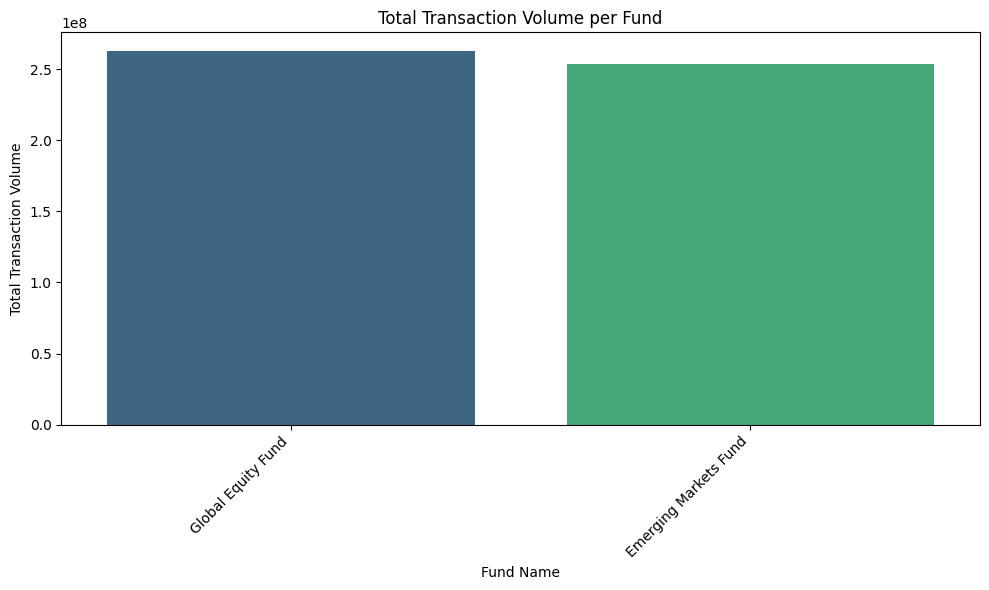

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for transaction volume
plt.figure(figsize=(10, 6))
sns.barplot(x='fund_name', y='total_transaction_volume', data=top_transactions_volume, palette='viridis', hue='fund_name', legend=False)
plt.title('Total Transaction Volume per Fund')
plt.xlabel('Fund Name')
plt.ylabel('Total Transaction Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Average Transaction Amount per Fund Type

In [170]:
print("Average Transaction Amount per Fund Type:")
query_avg_transaction_per_fund_type = """
SELECT
    df.fund_type,
    AVG(ft.transaction_amount) AS average_transaction_amount
FROM fact_transactions ft
JOIN dim_fund df ON ft.fund_id = df.fund_id
GROUP BY df.fund_type
ORDER BY average_transaction_amount DESC;
"""
avg_transaction_per_fund_type = pd.read_sql(query_avg_transaction_per_fund_type, conn)
display(avg_transaction_per_fund_type)

Average Transaction Amount per Fund Type:


,fund_type,average_transaction_amount
0,Equity,109961.303495
